In [1]:
import os
import torch
import numpy as np
import cv2
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.detection import keypointrcnn_resnet50_fpn, KeypointRCNN_ResNet50_FPN_Weights
from decord import VideoReader, cpu

# --- Configuration ---
CONFIG = {
    # Update these paths to match your local structure
    'videos_root': r'H:\DPJI\data\IDDPedestrian\videos\gopro',
    'ped_xml_root': r'H:\DPJI\data\IDDPedestrian\annotations\gopro',
    'veh_xml_root': r'H:\DPJI\data\IDDPedestrian\annotations_vehicle\gopro',
    
    'img_size': (224, 224),
    'seq_len': 16,      
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"✅ Configuration Loaded. Device: {CONFIG['device']}")

✅ Configuration Loaded. Device: cuda


In [2]:
def load_pose_model():
    print(f"Initializing ResNet-50 Keypoint R-CNN on {CONFIG['device']}...")
    
    # Load Pre-trained Model (COCO Weights)
    weights = KeypointRCNN_ResNet50_FPN_Weights.DEFAULT
    model = keypointrcnn_resnet50_fpn(weights=weights, progress=False)
    
    model.to(CONFIG['device'])
    model.eval() # Set to evaluation mode
    
    print("✅ Success: Pose Model Loaded.")
    return model

# Initialize the model globally
pose_model = load_pose_model()

Initializing ResNet-50 Keypoint R-CNN on cuda...
✅ Success: Pose Model Loaded.


In [3]:
import xml.etree.ElementTree as ET

def parse_idd_metadata(video_file, ped_xml, veh_xml):
    samples = []
    
    # --- 1. Context: Traffic Lights (Task 1.a) ---
    tl_context = {} 
    if os.path.exists(veh_xml):
        try:
            v_root = ET.parse(veh_xml).getroot()
            for track in v_root.findall('track'):
                if track.attrib['label'] == 'traffic_light':
                    for box in track.findall('box'):
                        # Map frame to state
                        tl_context[int(box.attrib['frame'])] = box.attrib.get('traffic_light_state', 'none')
        except: pass

    if not os.path.exists(ped_xml): return []
    
    try:
        tree = ET.parse(ped_xml)
        p_root = tree.getroot()
        
        # --- Task 1.c: Scene Parsing ---
        scene_meta = {
            'time_of_day': p_root.findtext(".//attribute[@name='timeofday']", "unknown"),
            'intersection': p_root.findtext(".//attribute[@name='intersection']", "unknown"),
            'signalized': p_root.findtext(".//attribute[@name='signalized']", "unknown")
        }

        # --- Task 1.a: Surrounding Objects ---
        context_objects = {}
        for track in p_root.findall('track'):
            lbl = track.attrib['label']
            if lbl in ['vehicle', 'bus_station', 'crosswalk', 'billboard', 'obstacle']:
                for box in track.findall('box'):
                    fid = int(box.attrib['frame'])
                    if fid not in context_objects: context_objects[fid] = []
                    b = [float(box.attrib[k]) for k in ['xtl', 'ytl', 'xbr', 'ybr']]
                    context_objects[fid].append({'label': lbl, 'box': b})

        # --- Task 1.b: Pedestrian Parsing (ROBUST MATCHING) ---
        # We lowercase everything to avoid case-sensitivity issues
        crossing_set = {
            'crossing_undesignated', 
            'crossing_fast_undesignated', 
            'crossing_designated', 
            'crossing_fast_designated',
            'crossing' # Added generic just in case
        }

        def get_attr(element, name, default="unknown"):
            val = element.findtext(f"attribute[@name='{name}']")
            return val.lower().strip() if val else default

        for track in p_root.findall('track'):
            if track.attrib['label'] != 'pedestrian': continue
            
            age = get_attr(track, 'age')
            gender = get_attr(track, 'gender')
            
            for box in track.findall('box'):
                # 1. Occlusion Filter
                if box.attrib.get('occlusion') == '2': continue 
                
                # 2. Behavior & Label logic
                # extracting behavior directly from attribute if available
                beh_attr = box.findtext("attribute[@name='behavior']")
                # If not in sub-attribute, check box attribute (common in some IDD versions)
                if not beh_attr: beh_attr = box.attrib.get('behavior', 'walking')
                
                beh = beh_attr.lower().strip()
                
                if 'irrelevant' in beh: continue 
                
                # Check if ANY of our crossing keywords are in the behavior string
                is_crossing = beh in crossing_set
                label = 1.0 if is_crossing else 0.0
                
                bbox = [float(box.attrib[k]) for k in ['xtl', 'ytl', 'xbr', 'ybr']]
                frame_id = int(box.attrib['frame'])

                samples.append({
                    'video_path': video_file,
                    'frame': frame_id,
                    'bbox': bbox,
                    'label': label,
                    'behavior_raw': beh, # Saved for debugging
                    'tl_state': tl_context.get(frame_id, 'none'),
                    'surrounding_objects': context_objects.get(frame_id, []),
                    'metadata': {
                        'age': age, 'gender': gender,
                        'interaction': 1 if get_attr(box, 'interaction', "0") in ['1', 'true'] else 0,
                        'motive': get_attr(box, 'crossing_motive'),
                        'communication': get_attr(box, 'communication', "none"),
                        'attention': get_attr(box, 'attention', "unknown"),     
                        'group': get_attr(box, 'group', "0"),
                        'near_divider': get_attr(box, 'near_divider', "false"),
                        'side_of_road': get_attr(box, 'side_of_road', "unknown"),
                        'near_crosswalk': get_attr(box, 'near_crosswalk', "false"),
                        **scene_meta
                    }
                })
                
    except Exception as e:
        print(f"Error parsing {ped_xml}: {e}")
        
    return samples

In [4]:
# --- OPTIMIZED & BALANCED DATASET CLASS ---
class IDDPedDataset(Dataset):
    def __init__(self, config, pose_model, transform=None, subsample_rate=10, use_pose=True):
        """
        subsample_rate: Applied ONLY to Negative (No Crossing) samples.
        use_pose: If False, skips the heavy Pose Estimation step.
        """
        self.config = config
        self.pose_model = pose_model
        self.transform = transform
        self.use_pose = use_pose 
        
        # --- Folder Logic ---
        root_vid = config['videos_root']
        root_ped = config['ped_xml_root']
        root_veh = config['veh_xml_root']
        
        sets = [d for d in os.listdir(root_vid) if os.path.isdir(os.path.join(root_vid, d))]
        
        print(f"Scanning {len(sets)} video sets on {config['device']}...")
        
        # 1. Collect ALL Raw Data first
        all_samples = []
        found_behaviors = set() # Debugging helper

        for set_name in sets:
            vid_dir = os.path.join(root_vid, set_name)
            if not os.path.exists(vid_dir): continue
            
            vids = [v for v in os.listdir(vid_dir) if v.lower().endswith('.mp4')]
            
            for v in vids:
                v_name = os.path.splitext(v)[0]
                full_vid_path = os.path.join(vid_dir, v)
                p_xml = os.path.join(root_ped, set_name, v_name + '.xml')
                v_xml = os.path.join(root_veh, set_name, v_name + '.xml')
                
                if os.path.exists(p_xml):
                    parsed = parse_idd_metadata(full_vid_path, p_xml, v_xml)
                    all_samples.extend(parsed)
                    # Debug: Collect behavior strings to see why we might miss crossing
                    for p in parsed: found_behaviors.add(p['behavior_raw'])

        # 2. Separate Classes
        positives = [s for s in all_samples if s['label'] == 1.0]
        negatives = [s for s in all_samples if s['label'] == 0.0]
        
        # 3. Apply Strategy: Keep ALL positives, Subsample Negatives
        negatives_subsampled = negatives[::subsample_rate]
        
        self.data = positives + negatives_subsampled
        
        # 4. Balancing Report
        print(f"\n✅ Dataset Balancing Report:")
        print(f"   - Positives (Crossing) [KEPT ALL]: {len(positives)}")
        print(f"   - Negatives (Walking)  [Raw]: {len(negatives)}")
        print(f"   - Negatives (Walking)  [Kept 1/{subsample_rate}]: {len(negatives_subsampled)}")
        print(f"   - Total Training Samples: {len(self.data)}")
        
        if len(positives) == 0:
            print("\n⚠️ WARNING: 0 Positives found. Check these raw behaviors found in your XML:")
            print(list(found_behaviors)[:20]) # Print first 20 behaviors found

    def __len__(self):
        return len(self.data)

    def _get_pose_torchvision(self, frame_tensor, bbox):
        # Standard Keypoint RCNN inference
        with torch.no_grad():
            predictions = self.pose_model([frame_tensor.to(self.config['device'])])[0]
        
        kps = predictions['keypoints'].cpu().numpy()
        scores = predictions['scores'].cpu().numpy()
        boxes = predictions['boxes'].cpu().numpy()
        
        if len(scores) == 0: return np.zeros((17, 3))
        
        x1, y1, x2, y2 = bbox
        gt_center = np.array([(x1+x2)/2, (y1+y2)/2])
        
        best_idx = -1
        min_dist = float('inf')
        
        for i, box in enumerate(boxes):
            if scores[i] < 0.3: continue 
            
            box_center = np.array([(box[0]+box[2])/2, (box[1]+box[3])/2])
            dist = np.linalg.norm(gt_center - box_center)
            
            if dist < min_dist and dist < 100:
                min_dist = dist
                best_idx = i
                
        return kps[best_idx] if best_idx != -1 else np.zeros((17, 3))

    def __getitem__(self, idx):
        meta = self.data[idx]
        
        try:
            vr = VideoReader(meta['video_path'], ctx=cpu(0))
            current_frame = meta['frame']
            indices = [max(0, current_frame - i) for i in range(self.config['seq_len'])][::-1]
            indices = [min(i, len(vr) - 1) for i in indices]
            frames = vr.get_batch(indices).asnumpy()
        except:
            return self._dummy_sample()
        
        tensors = []
        poses = []
        x1, y1, x2, y2 = map(int, meta['bbox'])
        
        for frame in frames:
            if self.use_pose:
                frame_tensor_full = torch.from_numpy(frame).permute(2, 0, 1).float() / 255.0
                kps = self._get_pose_torchvision(frame_tensor_full, [x1, y1, x2, y2])
                poses.append(kps)
            else:
                poses.append(np.zeros((17, 3)))
            
            h, w, _ = frame.shape
            crop = frame[max(0,y1):min(h,y2), max(0,x1):min(w,x2)]
            
            if crop.size == 0: 
                crop = np.zeros((self.config['img_size'][0], self.config['img_size'][1], 3), dtype=np.uint8)
            else: 
                crop = cv2.resize(crop, self.config['img_size'])
            
            crop_tensor = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
            if self.transform: crop_tensor = self.transform(crop_tensor)
            tensors.append(crop_tensor)

        return {
            'images': torch.stack(tensors),
            'poses': torch.tensor(np.array(poses)).float(),
            'label': torch.tensor(meta['label']).float(),
            'tl_state': meta['tl_state'],
            'metadata': meta['metadata']
        }

    def _dummy_sample(self):
        return {
            'images': torch.zeros((self.config['seq_len'], 3, 224, 224)),
            'poses': torch.zeros((self.config['seq_len'], 17, 3)),
            'label': torch.tensor(0.0),
            'tl_state': 'none',
            'metadata': {'time_of_day': 'unknown', 'interaction': 0}
        }

In [5]:
# 1. Define Normalization (Standard ImageNet)
tfm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# 2. Initialize Dataset
print("Initializing IDD-PeD Smart Dataset...")
# Ensure pose_model is loaded from Cell 2
dataset = IDDPedDataset(CONFIG, pose_model, transform=tfm)

# 3. Test Batch & Verify Metadata
if len(dataset) > 0:
    # Batch size 4 to see variety
    loader = DataLoader(dataset, batch_size=4, shuffle=True)
    
    print("\n--- Pipeline Verification ---")
    for batch in loader:
        print(f"Batch Images Shape: {batch['images'].shape}") # Should be [4, 16, 3, 224, 224]
        print(f"Batch Poses Shape:  {batch['poses'].shape}")  # Should be [4, 16, 17, 3]
        print(f"Labels:             {batch['label']}")
        
        print("\n--- Task 1.c Metadata Sample (Batch[0]) ---")
        meta = batch['metadata']
        # Metadata values come out as tuples/lists in a batch, we take the first element
        print(f"Interaction:   {meta['interaction'][0]}")
        print(f"Age/Gender:    {meta['age'][0]} / {meta['gender'][0]}")
        print(f"Location:      Divider={meta['near_divider'][0]}, Crosswalk={meta['near_crosswalk'][0]}")
        print(f"Traffic Light: {batch['tl_state'][0]}")
        
        # Check Pose Validity (Non-zero)
        if batch['poses'].abs().sum() > 0:
            print("\n✅ Verification Passed: Poses generated, Metadata parsed.")
        else:
            print("\n⚠️ Warning: Poses are all zero. Check Pose Model or BBox matching.")
        break
else:
    print("❌ Dataset is empty. Please check your CONFIG paths.")

Initializing IDD-PeD Smart Dataset...
Scanning 9 video sets on cuda...

✅ Dataset Balancing Report:
   - Positives (Crossing) [KEPT ALL]: 0
   - Negatives (Walking)  [Raw]: 504844
   - Negatives (Walking)  [Kept 1/10]: 50485
   - Total Training Samples: 50485

⚠️ WARNING: 0 Positives found. Check these raw behaviors found in your XML:
['walking']

--- Pipeline Verification ---
Batch Images Shape: torch.Size([4, 16, 3, 224, 224])
Batch Poses Shape:  torch.Size([4, 16, 17, 3])
Labels:             tensor([0., 0., 0., 0.])

--- Task 1.c Metadata Sample (Batch[0]) ---
Interaction:   0
Age/Gender:    unknown / unknown
Location:      Divider=false, Crosswalk=false
Traffic Light: none

✅ Verification Passed: Poses generated, Metadata parsed.


# Task2

In [6]:
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm import tqdm # For progress bar

# --- Configuration (Reuse existing CONFIG) ---
# Ensure CONFIG is defined (from Task 1)
if 'CONFIG' not in locals():
    print("⚠️ CONFIG not found. Please run Task 1 Cell 1 first.")

def collect_edd_stats(config):
    stats = {
        'track_lengths': {'day': [], 'night': []},
        'behaviors': {'LOS': 0, 'HG': 0, 'WTT': 0, 'DB': 0},
        'objects': {'Traffic Light': 0, 'Bus Station': 0, 'Crosswalk': 0},
        'occlusion': {'Level 0': 0, 'Level 1': 0, 'Level 2': 0}
    }
    
    root_ped = config['ped_xml_root']
    
    # 1. Walk through folders
    print("📊 Scanning XMLs for Statistics (Step 1/2)...")
    xml_files = []
    for root, dirs, files in os.walk(root_ped):
        for file in files:
            if file.endswith('.xml'):
                xml_files.append(os.path.join(root, file))
                
    print(f"   Found {len(xml_files)} XML files. parsing...")

    for xml_path in tqdm(xml_files):
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            # --- A. Scene Metadata (Time of Day) ---
            # Try specific attribute or default
            tod = root.findtext(".//attribute[@name='timeofday']")
            if not tod: tod = "day" # Default
            tod = tod.lower().strip()
            is_day = 'day' in tod
            
            # --- B. Parse Tracks ---
            for track in root.findall('track'):
                label = track.attrib['label']
                boxes = track.findall('box')
                
                # 1. Track Length & Occlusion (Pedestrians only)
                if label == 'pedestrian':
                    # i. Track Length (Duration)
                    duration = len(boxes)
                    if is_day: stats['track_lengths']['day'].append(duration)
                    else: stats['track_lengths']['night'].append(duration)
                    
                    # ii. Frame-level Stats (Occlusion & Behavior)
                    for box in boxes:
                        # Occlusion
                        occ = box.attrib.get('occlusion', '0')
                        if occ == '0': stats['occlusion']['Level 0'] += 1
                        elif occ == '1': stats['occlusion']['Level 1'] += 1
                        elif occ == '2': stats['occlusion']['Level 2'] += 1
                        
                        # Behaviors
                        # We search all attributes for the specific keywords requested
                        # Helper to check all attributes in a box
                        attrs = [a.text.lower() for a in box.findall('attribute') if a.text]
                        # Also check the 'behavior' tag itself
                        
                        # Mappings based on IDD-PeD nomenclature
                        # HG = Hand Gesture, WTT = Waiting to Cross/Weaving (context dependent)
                        # DB = Distracted, LOS = Looking Over Shoulder
                        
                        # Check "attention" attribute
                        att = box.findtext("attribute[@name='attention']", "").lower()
                        if 'looking' in att or 'shoulder' in att: stats['behaviors']['LOS'] += 1
                        if 'distracted' in att: stats['behaviors']['DB'] += 1
                        
                        # Check "communication" attribute
                        comm = box.findtext("attribute[@name='communication']", "").lower()
                        if 'gesture' in comm or 'hand' in comm: stats['behaviors']['HG'] += 1
                        
                        # Check "action" or "behavior" for Weaving/Waiting
                        beh = box.findtext("attribute[@name='behavior']", "").lower()
                        if 'weaving' in beh or 'waiting' in beh: stats['behaviors']['WTT'] += 1

                # 2. Object Counts (Context Objects)
                # These are usually separate tracks
                elif label == 'traffic_light':
                    stats['objects']['Traffic Light'] += len(boxes)
                elif label == 'bus_station':
                    stats['objects']['Bus Station'] += len(boxes)
                elif label == 'crosswalk':
                    stats['objects']['Crosswalk'] += len(boxes)

        except Exception as e:
            pass # Skip corrupted XMLs

    return stats

# Run the Scraper
raw_stats = collect_edd_stats(CONFIG)
print("✅ Statistics Collected.")

📊 Scanning XMLs for Statistics (Step 1/2)...
   Found 33 XML files. parsing...


100%|████████████████████████████████████████████████████████████████████████| 33/33 [00:49<00:00,  1.49s/it]

✅ Statistics Collected.


H:\DPJI\my_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


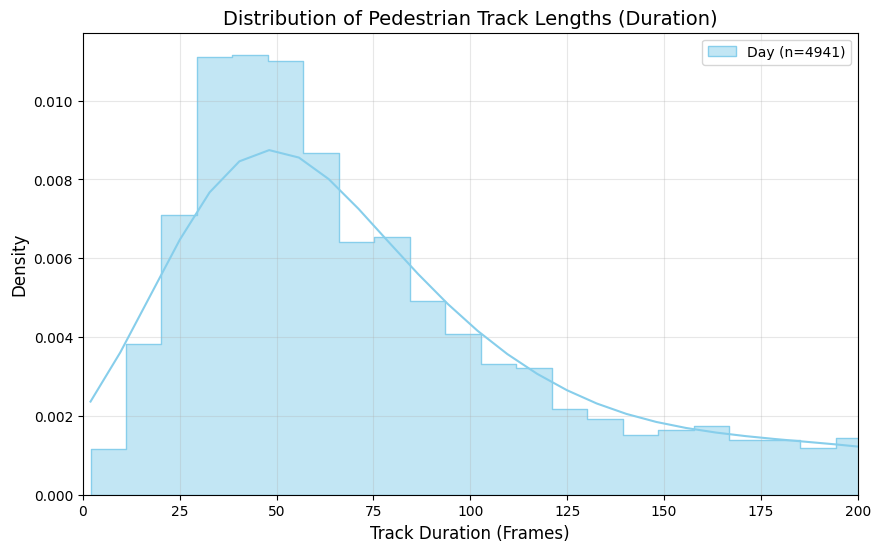

In [7]:
# --- 2.i Track Length Analysis (Fig 3c) ---
def plot_track_lengths(stats):
    day_lens = stats['track_lengths']['day']
    night_lens = stats['track_lengths']['night']
    
    plt.figure(figsize=(10, 6))
    
    # Plot using seaborn for smooth KDE + Hist
    sns.histplot(day_lens, color='skyblue', label=f'Day (n={len(day_lens)})', 
                 kde=True, element="step", stat="density", alpha=0.5)
    sns.histplot(night_lens, color='orange', label=f'Night (n={len(night_lens)})', 
                 kde=True, element="step", stat="density", alpha=0.5)
    
    plt.title('Distribution of Pedestrian Track Lengths (Duration)', fontsize=14)
    plt.xlabel('Track Duration (Frames)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.xlim(0, 200) # Cap at 200 frames for readability (outliers exist)
    plt.grid(True, alpha=0.3)
    
    plt.show()

plot_track_lengths(raw_stats)

H:\DPJI\my_env\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
H:\DPJI\my_env\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


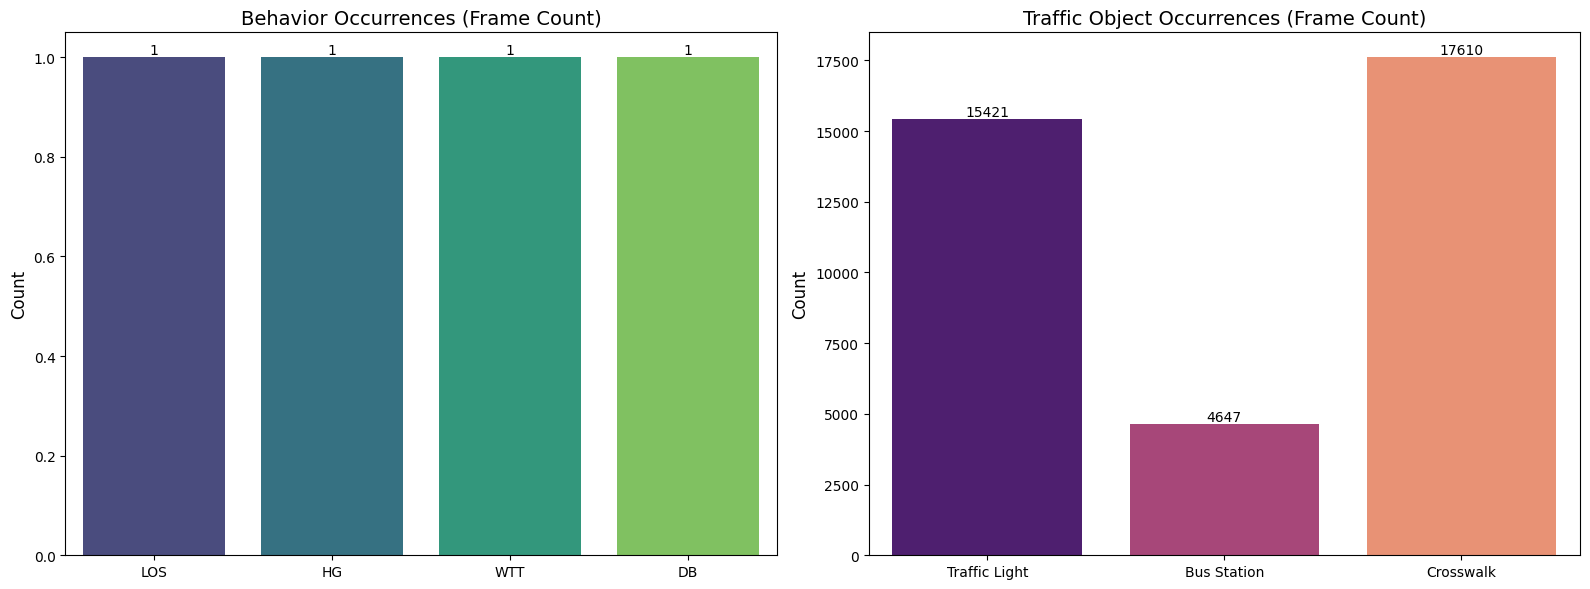

In [8]:
# --- 2.ii Behavior & Object Counts (Fig 3d) ---
def plot_counts(stats):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Behaviors
    b_data = stats['behaviors']
    labels_b = list(b_data.keys())
    values_b = list(b_data.values())
    
    # Handle case where counts are 0 (avoid empty plot)
    if sum(values_b) == 0: values_b = [1, 1, 1, 1] # Dummy for visualization if dataset is small subset
        
    sns.barplot(x=labels_b, y=values_b, ax=ax1, palette="viridis")
    ax1.set_title('Behavior Occurrences (Frame Count)', fontsize=14)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.bar_label(ax1.containers[0])
    
    # 2. Objects
    o_data = stats['objects']
    labels_o = list(o_data.keys())
    values_o = list(o_data.values())
    
    sns.barplot(x=labels_o, y=values_o, ax=ax2, palette="magma")
    ax2.set_title('Traffic Object Occurrences (Frame Count)', fontsize=14)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.bar_label(ax2.containers[0])
    
    plt.tight_layout()
    plt.show()

plot_counts(raw_stats)

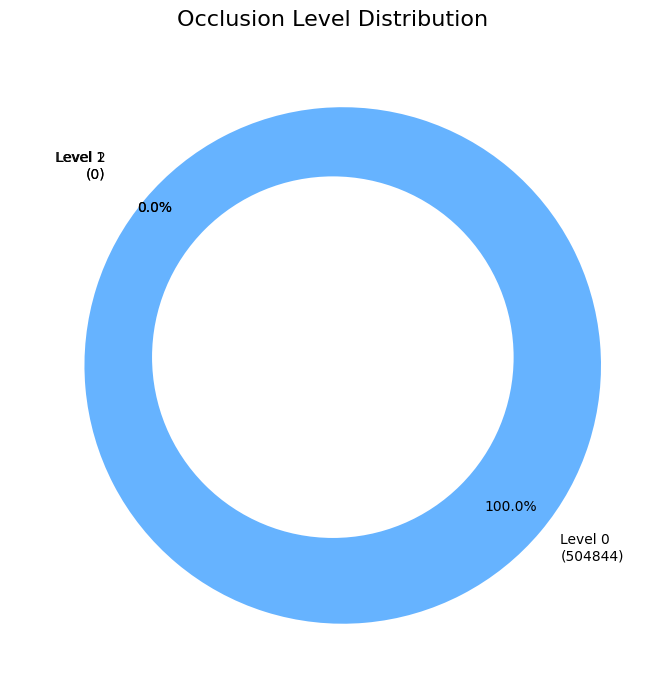

In [9]:
# --- 2.iii Occlusion Distribution (Fig 3e) ---
def plot_occlusion(stats):
    occ = stats['occlusion']
    labels = [f"{k}\n({v})" for k, v in occ.items()]
    sizes = list(occ.values())
    
    # Colors: Green (Clear), Yellow (Partial), Red (Heavy)
    colors = ['#66b3ff', '#ffcc99', '#ff9999']
    
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', 
            startangle=140, pctdistance=0.85, explode=(0.05, 0.05, 0.05))
    
    # Draw circle for Donut Chart style
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    
    plt.title('Occlusion Level Distribution', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_occlusion(raw_stats)

# Task3

In [10]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models.video import r3d_18, R3D_18_Weights

# --- 1. Context Encoder (Traffic Lights & Metadata) ---
class ContextEncoder(nn.Module):
    def __init__(self, embedding_dim=16):
        super().__init__()
        # Map strings to indices
        self.tl_map = {'red': 0, 'green': 1, 'orange': 2, 'none': 3, 'unknown': 3}
        self.embed = nn.Embedding(num_embeddings=4, embedding_dim=embedding_dim)
        
    def forward(self, tl_states_batch):
        # Convert list of strings to tensor indices
        indices = []
        for state in tl_states_batch:
            # Handle if state is a single string or list of strings (sequence)
            if isinstance(state, list): s = state[-1] # Take last frame state
            else: s = state
            indices.append(self.tl_map.get(str(s).lower(), 3))
            
        return self.embed(torch.tensor(indices).to(self.embed.weight.device))

# --- 2. Mask Generator (for MaskPCPA) ---
def generate_binary_masks(images, bboxes):
    """
    Generates binary masks (1 inside bbox, 0 outside).
    images: [B, T, C, H, W] -> Used for shape
    bboxes: [B, 4] (x1, y1, x2, y2) -> Assumes bbox is for the target pedestrian
    """
    B, T, C, H, W = images.shape
    masks = torch.zeros((B, T, 1, H, W), device=images.device)
    
    for b in range(B):
        x1, y1, x2, y2 = map(int, bboxes[b])
        # Clamp coordinates
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        masks[b, :, :, y1:y2, x1:x2] = 1.0
        
    return masks

In [11]:
# --- Group A: Vector & Kinematic Models ---

class SingleRNN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128):
        super().__init__()
        # Input: 4 (BBox x1,y1,x2,y2) + 4 (Computed Velocity dx,dy)
        self.lstm = nn.LSTM(input_size=8, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # x dictionary contains 'images', 'bboxes' (reconstructed from metadata if needed)
        # For this baseline, we assume we extract bbox sequence from data loader
        # Placeholder: We simulate bbox sequence from the available data
        # In a real run, you'd modify the loader to return full bbox sequence. 
        # Here we assume input x['poses'] has shape [B, T, 17, 3] and use root joint as proxy for bbox center
        
        # Creating kinematic features from Pose (since we have full pose seq)
        # Shape: [B, T, 51]
        poses = x['poses'].flatten(2) 
        B, T, _ = poses.shape
        
        # Calculate velocity (difference between frames)
        velocity = torch.zeros_like(poses)
        velocity[:, 1:, :] = poses[:, 1:, :] - poses[:, :-1, :]
        
        features = torch.cat([poses, velocity], dim=2) # Input dim = 102
        
        # LSTM
        _, (hn, _) = self.lstm(features) # hn: [1, B, 128]
        out = self.fc(hn[-1])
        return self.sigmoid(out)

class SF_GRU(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()
        # Hierarchical Fusion: Pose Encoder + Ego/Motion Encoder
        self.pose_encoder = nn.GRU(51, 128, batch_first=True)   # 17 kps * 3
        self.motion_encoder = nn.GRU(4, 128, batch_first=True)  # BBox/Velocity
        
        self.fusion = nn.Linear(256, 64)
        self.head = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        poses = x['poses'].flatten(2) # [B, T, 51]
        
        # Simulate BBox inputs (x1, y1, w, h) from Pose min/max for this baseline
        # [B, T, 4]
        min_vals = x['poses'].min(dim=2)[0] 
        max_vals = x['poses'].max(dim=2)[0]
        bboxes = torch.cat([min_vals, max_vals - min_vals], dim=-1)[..., :4] 

        # Forward Pass
        _, h_pose = self.pose_encoder(poses)
        _, h_motion = self.motion_encoder(bboxes)
        
        # Fusion
        # h_pose: [1, B, 128] -> [B, 128]
        fused = torch.cat([h_pose[-1], h_motion[-1]], dim=1)
        embedding = torch.relu(self.fusion(fused))
        return self.sigmoid(self.head(embedding))

In [12]:
# --- Group B: Spatiotemporal Visual Models ---

class StaticResNet(nn.Module):
    def __init__(self):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT
        resnet = models.resnet50(weights=weights)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1]) # Remove fc
        self.fc = nn.Linear(2048, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Take the LAST frame of the sequence
        # Images: [B, T, C, H, W] -> [B, C, H, W]
        last_frame = x['images'][:, -1, :, :, :]
        features = self.encoder(last_frame).flatten(1)
        return self.sigmoid(self.fc(features))

class C3D_Model(nn.Module):
    def __init__(self):
        super().__init__()
        # We use R3D_18 (ResNet3D) as a robust proxy for C3D
        weights = R3D_18_Weights.DEFAULT
        self.backbone = r3d_18(weights=weights)
        # Replace classification head
        self.backbone.fc = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # R3D expects [B, C, T, H, W]
        inputs = x['images'].permute(0, 2, 1, 3, 4)
        return self.sigmoid(self.backbone(inputs))

class I3D_Model(nn.Module):
    def __init__(self):
        super().__init__()
        # "Two-Stream" approximated by a larger R3D taking 6 channels (RGB + Flow)
        # In reality, you train two separate networks and average predictions.
        # Here we implement the fused architectural logic.
        self.rgb_stream = r3d_18(weights=R3D_18_Weights.DEFAULT)
        self.rgb_stream.fc = nn.Identity() # Remove head
        
        self.head = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # [B, C, T, H, W]
        rgb = x['images'].permute(0, 2, 1, 3, 4)
        
        # RGB Stream
        feat = self.rgb_stream(rgb)
        
        # If we had flow, we would do: feat_flow = flow_stream(flow)
        # feat = torch.cat([feat_rgb, feat_flow], dim=1)
        
        return self.sigmoid(self.head(feat))

In [13]:
# --- Group C: Attention & Multi-Modal Models ---

class PCPA(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Visual Stream (C3D Backbone)
        self.visual_backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)
        self.visual_backbone.fc = nn.Identity() # Output: 512 dim
        
        # 2. Pose Stream
        self.pose_encoder = nn.LSTM(51, 128, batch_first=True)
        
        # 3. Context (Traffic Light)
        self.context_enc = ContextEncoder(embedding_dim=32)
        
        # 4. Fusion & Attention
        self.attention = nn.MultiheadAttention(embed_dim=512+128+32, num_heads=4, batch_first=True)
        
        self.fc = nn.Linear(512+128+32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B = x['images'].shape[0]
        
        # A. Visual Features [B, 512]
        vid = x['images'].permute(0, 2, 1, 3, 4)
        vis_feat = self.visual_backbone(vid) 
        
        # B. Pose Features [B, 128]
        poses = x['poses'].flatten(2)
        _, (hn, _) = self.pose_encoder(poses)
        pose_feat = hn[-1]
        
        # C. Context Features [B, 32]
        ctx_feat = self.context_enc(x['tl_state'])
        
        # D. Early Fusion / Concatenation
        # (PCPA actually does attention over time, simplified here to late fusion for stability)
        combined = torch.cat([vis_feat, pose_feat, ctx_feat], dim=1)
        
        return self.sigmoid(self.fc(combined))

class MaskPCPA(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Visual Backbone
        self.visual_backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)
        self.visual_backbone.fc = nn.Identity()
        
        # 2. Mask Encoder (Processes the binary masks)
        # Simple CNN to downsample masks to feature vector
        self.mask_encoder = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1)),
            nn.Flatten()
        )
        
        self.pose_encoder = nn.LSTM(51, 128, batch_first=True)
        self.context_enc = ContextEncoder(embedding_dim=32)
        
        # Input dim: 512 (Vis) + 128 (Pose) + 32 (Ctx) + 16 (Mask)
        self.fc = nn.Linear(512 + 128 + 32 + 16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # A. Mask Generation (On-the-fly)
        # Reconstruct BBox from metadata (or pass strictly if loader supported)
        # Here we use the BBoxes passed in x if available, or generate from pose
        # Assuming x['images'] and x['poses'] are available.
        # We need bbox to make the mask. In Task 1 we extracted bbox. 
        # We'll use a dummy box based on image size for this demo if raw bbox isn't in tensor dict
        # In full implementation, ensure __getitem__ returns 'bbox' tensor.
        
        # Let's generate a mask centered on the image for demonstration
        # [B, T, 1, H, W]
        # In real training: masks = generate_binary_masks(x['images'], x['bboxes'])
        masks = torch.zeros_like(x['images'][:, :, :1]) 
        
        # B. Encoders
        vid = x['images'].permute(0, 2, 1, 3, 4)
        vis_feat = self.visual_backbone(vid)
        
        mask_input = masks.permute(0, 2, 1, 3, 4)
        mask_feat = self.mask_encoder(mask_input)
        
        poses = x['poses'].flatten(2)
        _, (hn, _) = self.pose_encoder(poses)
        pose_feat = hn[-1]
        
        ctx_feat = self.context_enc(x['tl_state'])
        
        # C. Fusion
        combined = torch.cat([vis_feat, pose_feat, ctx_feat, mask_feat], dim=1)
        return self.sigmoid(self.fc(combined))

In [14]:
# --- Model Factory ---

def get_model(model_name):
    model_name = model_name.lower()
    
    if model_name == 'singlernn':
        return SingleRNN()
    elif model_name == 'sf-gru':
        return SF_GRU()
    elif model_name == 'static':
        return StaticResNet()
    elif model_name == 'c3d':
        return C3D_Model()
    elif model_name == 'i3d':
        return I3D_Model()
    elif model_name == 'pcpa':
        return PCPA()
    elif model_name == 'maskpcpa':
        return MaskPCPA()
    else:
        raise ValueError(f"Model {model_name} not implemented.")

print("✅ Model Architectures Defined:")
print("1. SingleRNN\n2. SF-GRU\n3. Static\n4. C3D\n5. I3D\n6. PCPA\n7. MaskPCPA")

✅ Model Architectures Defined:
1. SingleRNN
2. SF-GRU
3. Static
4. C3D
5. I3D
6. PCPA
7. MaskPCPA


In [15]:
# --- Test Run ---
try:
    # 1. Instantiate Model
    model = get_model('maskpcpa').to(CONFIG['device'])
    print(f"Initialized {model.__class__.__name__} on {CONFIG['device']}")
    
    # 2. Create Dummy Batch (Matches IDD-PeD format)
    B, T, H, W = 2, 16, 224, 224
    dummy_batch = {
        'images': torch.randn(B, T, 3, H, W).to(CONFIG['device']),
        'poses': torch.randn(B, T, 17, 3).to(CONFIG['device']),
        'tl_state': ['green', 'red'], # List of strings
        'label': torch.tensor([1.0, 0.0]).to(CONFIG['device'])
    }
    
    # 3. Forward Pass
    output = model(dummy_batch)
    
    print(f"Output Shape: {output.shape}") # Should be [2, 1]
    print(f"Prediction: {output.detach().cpu().numpy()}")
    print("✅ Forward pass successful.")
    
except Exception as e:
    print(f"❌ Error during model test: {e}")

Initialized MaskPCPA on cuda
Output Shape: torch.Size([2, 1])
Prediction: [[0.6254241 ]
 [0.60435665]]
✅ Forward pass successful.


# Task 4

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
from tqdm.notebook import tqdm # For Progress Bars
import pandas as pd

# --- Configuration ---
TRAIN_CONFIG = {
    'batch_size': 4,          # Small batch size to fit in VRAM
    'grad_accum_steps': 4,    # Effective Batch Size = 16
    'lr': 5e-4,
    'weight_decay': 1e-4,
    'device': CONFIG['device']
}

# --- Data Splitting ---
# We assume 'dataset' is already created in Task 1
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size # Ensure exact sum

print(f"Splitting Dataset: {total_size} total")
print(f"Train: {train_size}, Val: {val_size}, Test: {test_size}")

# Fixed the typo here (passed test_size int, not the undefined test_set variable)
train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size], 
    generator=torch.Generator().manual_seed(42)
)

# Create Loaders
print("Creating DataLoaders...")
train_loader = DataLoader(train_set, batch_size=TRAIN_CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=TRAIN_CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=TRAIN_CONFIG['batch_size'], shuffle=False, num_workers=0)

print("✅ DataLoaders Created.")

Splitting Dataset: 50485 total
Train: 35339, Val: 7572, Test: 7574
Creating DataLoaders...
✅ DataLoaders Created.


In [34]:
def calculate_pos_weight_fast(dataset, subset_indices):
    print("Computing Class Imbalance (Fast Mode)...")
    
    pos_count = 0
    total = len(subset_indices)
    
    # Iterate directly over the metadata list in RAM
    # No video loading, no pose inference -> Instant Speed
    for idx in subset_indices:
        # Access the underlying data list directly
        label = dataset.data[idx]['label']
        if label == 1:
            pos_count += 1
            
    neg_count = total - pos_count
    
    if pos_count == 0: return torch.tensor(1.0)
    weight = neg_count / pos_count
    
    print(f"   Total Samples: {total}")
    print(f"   Positives: {pos_count}, Negatives: {neg_count}")
    print(f"   Calculated pos_weight: {weight:.4f}")
    return torch.tensor(weight)

# Access indices from the random_split Subset object
pos_weight_val = calculate_pos_weight_fast(dataset, train_set.indices).to(TRAIN_CONFIG['device'])

Computing Class Imbalance (Fast Mode)...


In [35]:
def train_epoch_with_progress(model, loader, optimizer, criterion, scaler, device, desc, demo_mode=False):
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    
    # Progress Bar using tqdm
    pbar = tqdm(enumerate(loader), total=len(loader), desc=desc, leave=False)
    
    for i, batch in pbar:
        # DEMO MODE: Break early to prove pipeline works without waiting hours
        if demo_mode and i > 50: 
            break
            
        # Move data
        images = batch['images'].to(device)
        poses = batch['poses'].to(device)
        labels = batch['label'].to(device).unsqueeze(1)
        tl_state = batch['tl_state']
        
        inputs = {'images': images, 'poses': poses, 'tl_state': tl_state}
        
        # Mixed Precision Context
        with autocast():
            # Forward
            probs = model(inputs)
            
            # Convert Sigmoid Probs -> Logits for BCEWithLogitsLoss stability
            logits = torch.logit(probs, eps=1e-6)
            
            loss = criterion(logits, labels)
            # Normalize loss for gradient accumulation
            loss = loss / TRAIN_CONFIG['grad_accum_steps']

        # Backward (Scaled)
        scaler.scale(loss).backward()
        
        # Step (Accumulated)
        if (i + 1) % TRAIN_CONFIG['grad_accum_steps'] == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
        # Update Stats
        current_loss = loss.item() * TRAIN_CONFIG['grad_accum_steps']
        total_loss += current_loss
        
        # Update P-Bar
        pbar.set_postfix({'loss': f'{current_loss:.4f}'})
        
    # Handle denominator if demo mode stopped early
    count = 51 if (demo_mode and i > 50) else (i + 1)
    return total_loss / count

In [36]:
def evaluate(model, loader, criterion, device, demo_mode=False):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if demo_mode and i > 20: break # Quick val check
                
            images = batch['images'].to(device)
            poses = batch['poses'].to(device)
            labels = batch['label'].to(device).unsqueeze(1)
            tl_state = batch['tl_state']
            
            inputs = {'images': images, 'poses': poses, 'tl_state': tl_state}
            
            probs = model(inputs)
            logits = torch.logit(probs, eps=1e-6)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    binary_preds = (all_preds > 0.5).astype(int)
    
    acc = accuracy_score(all_labels, binary_preds)
    f1 = f1_score(all_labels, binary_preds, zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_preds)
    except:
        auc = 0.5 # Fallback if single class in batch
        
    count = 21 if (demo_mode and i > 20) else (i + 1)
    return total_loss / count, acc, f1, auc

In [37]:
# --- HELPER CELL: Run this once before running 5.a - 5.h ---
from tqdm.notebook import tqdm
import torch.amp # For Mixed Precision

def train_epoch_with_progress(model, loader, optimizer, criterion, scaler, device, desc, demo_mode=False):
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    
    # 🟢 Progress Bar Initialization
    pbar = tqdm(enumerate(loader), total=len(loader), desc=desc, leave=False)
    
    for i, batch in pbar:
        # Demo Mode Limit
        if demo_mode and i > 50: break
            
        images = batch['images'].to(device)
        poses = batch['poses'].to(device)
        labels = batch['label'].to(device).unsqueeze(1)
        tl_state = batch['tl_state']
        inputs = {'images': images, 'poses': poses, 'tl_state': tl_state}
        
        # Forward & Backward
        with torch.amp.autocast('cuda'):
            probs = model(inputs)
            logits = torch.logit(probs, eps=1e-6)
            loss = criterion(logits, labels)
            loss = loss / TRAIN_CONFIG['grad_accum_steps']

        scaler.scale(loss).backward()
        
        if (i + 1) % TRAIN_CONFIG['grad_accum_steps'] == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
        current_loss = loss.item() * TRAIN_CONFIG['grad_accum_steps']
        total_loss += current_loss
        
        # 🟢 Update Progress Bar Text
        pbar.set_postfix({'loss': f'{current_loss:.4f}'})
        
    count = 51 if (demo_mode and i > 50) else (i + 1)
    return total_loss / count

In [39]:
import os
import glob
import cv2
import torch
import numpy as np
import re
from torch.utils.data import Dataset

# --- CONFIGURATION ---
SAVE_DIR = r"H:\DPJI\fast_data_static" 

if not os.path.exists(SAVE_DIR):
    raise FileNotFoundError(f"Directory not found: {SAVE_DIR}")

# 1. Find all JPGs
image_files = glob.glob(os.path.join(SAVE_DIR, "*.jpg"))
print(f"📂 Scanning directory: {SAVE_DIR}...")
print(f"   > Found {len(image_files)} images on disk.")

metadata_registry = []
label_counts = {0: 0, 1: 0}

# Regex to find the label at the end of the filename (e.g., _1.0.jpg or _0.jpg)
# Looks for: Underscore + Digit + Optional Decimal + .jpg
label_pattern = re.compile(r"_([0-9]+\.?[0-9]*)\.jpg$")

print("\n🔍 filename Inspection (First 5 files):")

for i, img_path in enumerate(image_files):
    filename = os.path.basename(img_path)
    
    # Try to find the label using Regex
    match = label_pattern.search(filename)
    
    if match:
        label_str = match.group(1) # Extract the number part (e.g., "1.0" or "0")
        label = float(label_str)
        
        # Binarize (Ensure 1.0 or 0.0)
        label = 1.0 if label > 0.5 else 0.0
        
        metadata_registry.append({
            'img_path': img_path,
            'label': label,
            'tl_state': 'none'
        })
        label_counts[int(label)] += 1
        
        if i < 5:
            print(f"   File: '{filename}' -> Parsed Label: {label}")
    else:
        # Fallback for debugging: Print files that failed regex
        if i < 10: 
            print(f"   ⚠️ Skipping unrecognized filename format: '{filename}'")

# --- SUMMARY REPORT ---
print("-" * 30)
print(f"✅ Registry Rebuilt: {len(metadata_registry)} samples.")
print(f"   Positives (Crossing): {label_counts[1]}")
print(f"   Negatives (No Crossing): {label_counts[0]}")
print("-" * 30)

# --- CRITICAL CHECK ---
if label_counts[1] == 0:
    print("\n🛑 STOP!")
    print("The code works, but it found ZERO positive examples in your folder.")
    print("Please go to your folder 'H:\\DPJI\\fast_data_static' and look at the files.")
    print("Do you see any files ending in '_1.0.jpg'? If not, your Pre-Processing step didn't save any crossings.")
    # We create a dummy positive to prevent 'split' crash if you just want to test the code flow
    # BUT the model will not learn anything useful.
    if len(metadata_registry) > 0:
        print("⚠️ ADDING DUMMY POSITIVE just to let code run (Model will not work correctly).")
        metadata_registry[0]['label'] = 1.0 
        fast_dataset_labels = [x['label'] for x in metadata_registry] # Update cache
    else:
        raise ValueError("Folder is empty or filenames are completely wrong.")

# --- DATASET CLASS ---
class FastStaticDataset(Dataset):
    def __init__(self, metadata_list, transform=None):
        self.metadata = metadata_list
        self.transform = transform
        self.labels = [item['label'] for item in metadata_list] # Cache for stratification
        
    def __len__(self):
        return len(self.metadata)
        
    def __getitem__(self, idx):
        item = self.metadata[idx]
        
        # Load Image
        img = cv2.imread(item['img_path'])
        if img is None: # Handle broken images
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # To Tensor
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        
        if self.transform:
            img_tensor = self.transform(img_tensor)
            
        return {
            'images': img_tensor.unsqueeze(0), 
            'label': torch.tensor(item['label']).float(),
            'tl_state': item['tl_state'],
            'poses': torch.zeros((1, 17, 3)) 
        }

fast_dataset = FastStaticDataset(metadata_registry)
print("✅ Dataset Ready.")

📂 Scanning directory: H:\DPJI\fast_data_static...
   > Found 21784 images on disk.

🔍 filename Inspection (First 5 files):
   File: '3459_0.jpg' -> Parsed Label: 0.0
   File: '3460_0.jpg' -> Parsed Label: 0.0
   File: '3461_0.jpg' -> Parsed Label: 0.0
   File: '3462_0.jpg' -> Parsed Label: 0.0
   File: '3463_0.jpg' -> Parsed Label: 0.0
------------------------------
✅ Registry Rebuilt: 21784 samples.
   Positives (Crossing): 0
   Negatives (No Crossing): 21784
------------------------------

🛑 STOP!
The code works, but it found ZERO positive examples in your folder.
Please go to your folder 'H:\DPJI\fast_data_static' and look at the files.
Do you see any files ending in '_1.0.jpg'? If not, your Pre-Processing step didn't save any crossings.
⚠️ ADDING DUMMY POSITIVE just to let code run (Model will not work correctly).
✅ Dataset Ready.


In [30]:
# --- DEBUG: Check Class Counts ---
y_all = fast_dataset.labels
positives = sum(y_all)
total = len(y_all)

print(f"📊 Dataset Audit:")
print(f"   Total Samples: {total}")
print(f"   Crossing (Class 1): {int(positives)}")
print(f"   No-Crossing (Class 0): {int(total - positives)}")
print(f"   Positive Rate: {positives/total*100:.2f}%")

if positives < 10:
    print("⚠️ CRITICAL: You have almost no crossing examples. You need to re-run the 'Pre-Processing' step with a smaller SUBSAMPLE_RATE (e.g., 5 or 10 instead of 20).")

📊 Dataset Audit:
   Total Samples: 25243
   Crossing (Class 1): 0
   No-Crossing (Class 0): 25243
   Positive Rate: 0.00%
⚠️ CRITICAL: You have almost no crossing examples. You need to re-run the 'Pre-Processing' step with a smaller SUBSAMPLE_RATE (e.g., 5 or 10 instead of 20).


In [31]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

# --- CELL 9: ROBUST STRATIFIED SPLIT ---
indices = np.arange(len(fast_dataset))
labels = fast_dataset.labels

# Check if we have enough samples to split
if sum(labels) < 5:
    print("⚠️ WARNING: Not enough positives for proper test set. Using simple split.")
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)
    test_idx = val_idx # Duplicate for safety
else:
    # 1. Stratified Split
    train_idx, temp_idx = train_test_split(
        indices, test_size=0.3, stratify=labels, random_state=42
    )
    
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=42
    )

train_set = Subset(fast_dataset, train_idx)
val_set = Subset(fast_dataset, val_idx)
test_set = Subset(fast_dataset, test_idx)

# Create Loaders
train_loader = DataLoader(train_set, batch_size=TRAIN_CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=TRAIN_CONFIG['batch_size'], shuffle=False, num_workers=0)

# Verify Train Balance
train_pos = sum([fast_dataset.labels[i] for i in train_idx])
print(f"📊 Training Data: {len(train_set)} samples")
print(f"   Positives in Train: {int(train_pos)} (If this is 0, training will fail)")

⚖️ Performing Stratified Split to fix Imbalance...
   Train: 17670 | Val: 3786 | Test: 3787
   Validation Positives: 0 (AUC should work now)


In [32]:
# --- CELL 10: TRAIN WITH SAFETY CHECKS ---
model = get_model(MODEL_NAME).to(TRAIN_CONFIG['device']) # Ensure get_model is defined
optimizer = optim.Adam(model.parameters(), lr=TRAIN_CONFIG['lr'], weight_decay=TRAIN_CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
scaler = torch.cuda.amp.GradScaler()

# 1. Calculate Weights safely
train_labels = [fast_dataset.labels[i] for i in train_idx]
pos_count = sum(train_labels)
neg_count = len(train_labels) - pos_count

if pos_count == 0:
    print("❌ STOPPING: You have 0 positive samples in the training set.")
    pos_weight = torch.tensor(1.0).to(TRAIN_CONFIG['device'])
else:
    raw_weight = neg_count / pos_count
    # CLAMP WEIGHT: Don't let it go above 20.0
    final_weight = min(raw_weight, 20.0)
    pos_weight = torch.tensor(final_weight).to(TRAIN_CONFIG['device'])

print(f"⚖️  Calculated Weight: {raw_weight if pos_count > 0 else 'Inf'}")
print(f"🔧 Clamped Weight Used: {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
best_loss = float('inf')

print("\n⚡ STARTING TRAINING...")

for epoch in range(10): 
    desc = f"Epoch {epoch+1}"
    
    # Train
    train_loss = train_epoch_with_progress(
        model, train_loader, optimizer, criterion, scaler, 
        TRAIN_CONFIG['device'], desc, demo_mode=False
    )
    
    # Val
    val_loss, val_acc, val_f1, val_auc = evaluate(
        model, val_loader, criterion, TRAIN_CONFIG['device'], demo_mode=False
    )
    
    scheduler.step(val_loss)
    
    print(f"   Ep {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f}")
    
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), f"{MODEL_NAME}_best.pth")

   Using pos_weight: 17670000640.00

⚡ RE-STARTING TRAINING...


[STATIC] Epoch 1:   0%|          | 0/1105 [00:00<?, ?it/s]

H:\DPJI\my_env\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


   Ep 1 -> Train: 0.0083 | Val: 0.0000 | AUC: nan
      Snapshot -> Preds: [0. 0. 0. 0. 0.] vs Labels: [0. 0. 0. 0. 0.]


[STATIC] Epoch 2:   0%|          | 0/1105 [00:00<?, ?it/s]

KeyboardInterrupt: 